# Supplementary Figure SR4 — two-component mixture of squared effect sizes

Supplementary Results 6 fits one- and two-component Gaussian mixtures to the squared absolute effect
sizes of each highly pleiotropic variant, and reports that 100 of 118 favour two components. SR4 is
the worked example: the squared effects of **one** variant, the histogram, both fitted component
densities, and the points coloured by the component they are assigned to.

**Which variant.** The published figure was drawn by
`~/Projects/EGL_and_training_set/archive/gentropy_paper/R_scripts/10_games_with_distirbutions.R`
(lines 150-200), from a vector of 20 $|\hat\beta|$ values pasted in by hand with no variant id
attached. Matching that vector against the release recovers it: **9_22124745_C_G**, the 9p21 locus.
The vector is reproduced below from the release and asserted against the archive's copy, so the
figure is drawn from the pipeline rather than from the paste.

**The 20 values are one row per disease, keeping the largest effect.** That is a single deduplication
pass, by variant and disease. The effect matrix of `03-analysis-supplementary/06` applies an earlier
pass as well — largest effect per variant and *study* — which for this variant drops one of its 20
diseases and leaves 19. Both are computed below; the 20-value set is the one the published figure
used, and it is what is plotted.

**The fit, and why it is not the one behind the S6 numbers.** The published figure was drawn with
`flexmix`; `06_variant_pleiotropy_modelling` counts the 118 variants and the 100 favouring two
components with `sklearn.mixture.GaussianMixture(random_state=123)`, whose default k-means
initialisation lands on a *worse* local optimum for this variant — log-likelihood 66.37 against
68.31, with the components split 4/16 and two density curves of near-equal height. The published
figure shows one narrow tall component and one broad low one, so it is the better optimum. Random
initialisation with 50 restarts reaches it, and reaches the same one from every seed tried
(0, 1, 7, 42, 123, 2024), so it is the global optimum rather than a lucky draw. That is what is
fitted below; both fits are printed, and the k-means one is the control for the S6 counts.

Component 1 is the larger-mean component, drawn in red as in the original, and component 2 the
smaller-mean one, in dark green.

Writes `figure_sr4.pdf`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
from matplotlib.lines import Line2D
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from manuscript_methods import paper

FIGURE_DIR = paper.ROOT / "chapters" / "05-figures-supplementary" / "supplementary"
VARIANT = "9_22124745_C_G"
RANDOM_STATE = 123
RESTARTS = 50
BINS = 20
JITTER_SEED = 0

# The vector pasted into the archive R script, kept as the control for what the published figure drew.
ARCHIVE_VALUES = np.array(
    [
        0.07883535278110519,
        0.030872661279000867,
        0.03891898167610717,
        0.05363171690758647,
        0.03850553581657284,
        0.13520505194742938,
        0.06502301093338424,
        0.07489795645306359,
        0.04365983747099578,
        0.11083026574244388,
        0.12445843669420355,
        0.07684962939896704,
        0.11580216127797223,
        0.22287798151967794,
        0.05991694265080245,
        0.1888225775300826,
        0.03891898167610717,
        0.05491866198626455,
        0.20340966480076852,
        0.2052254670613944,
    ]
)

## The variant's effects, from the release

In [2]:
qualifying = set(
    ds.dataset(paper.derived("qualifying_credible_sets"), format="parquet")
    .to_table(columns=["studyLocusId"])
    .column("studyLocusId")
    .to_pylist()
)
effects = (
    ds.dataset(paper.derived("lead_variant_effect"), format="parquet")
    .to_table(
        columns={
            "studyLocusId": ds.field("studyLocusId"),
            "studyId": ds.field("studyId"),
            "diseaseIds": ds.field("diseaseIds"),
            "absEstimatedBeta": pc.struct_field(ds.field("rescaledStatistics"), "absEstimatedBeta"),
        },
        filter=pc.field("variantId") == VARIANT,
    )
    .to_pandas()
)
effects = (
    effects[effects["studyLocusId"].isin(qualifying)].explode("diseaseIds").rename(columns={"diseaseIds": "diseaseId"})
)
print(
    f"{VARIANT}: {len(effects)} credible-set/disease rows | "
    f"{effects['studyId'].nunique()} studies | {effects['diseaseId'].nunique()} diseases"
)

# One row per disease, largest effect kept.
per_disease = effects.sort_values("absEstimatedBeta", ascending=False).drop_duplicates("diseaseId")
values = np.sort(per_disease["absEstimatedBeta"].to_numpy(dtype=float))
assert np.allclose(values, np.sort(ARCHIVE_VALUES), rtol=0, atol=1e-15)
print(f"one row per disease: {len(values)} effects — matches the archive vector exactly")

# The effect matrix of Supplementary Results 6 dedupes by study first, for comparison only.
by_study = effects.sort_values("absEstimatedBeta", ascending=False).drop_duplicates(["studyId"])
matrix_route = by_study.sort_values("absEstimatedBeta", ascending=False).drop_duplicates("diseaseId")
print(f"matrix route (study pass first): {len(matrix_route.dropna(subset=['absEstimatedBeta']))} effects")

9_22124745_C_G: 24 credible-set/disease rows | 23 studies | 20 diseases
one row per disease: 20 effects — matches the archive vector exactly
matrix route (study pass first): 19 effects


## The mixtures

In [3]:
squared = (values**2).reshape(-1, 1)
one = GaussianMixture(n_components=1, random_state=RANDOM_STATE).fit(squared)
two = GaussianMixture(n_components=2, random_state=RANDOM_STATE, n_init=RESTARTS, init_params="random").fit(squared)
assignment = two.predict(squared)

# The k-means initialisation the S6 counts use, for the record: a worse optimum on this variant.
kmeans_init = GaussianMixture(n_components=2, random_state=RANDOM_STATE).fit(squared)
print(
    f"log-likelihood — random init: {two.score(squared) * len(squared):.3f} | "
    f"k-means init (the S6 counts): {kmeans_init.score(squared) * len(squared):.3f}"
)
print(
    f"k-means-init means: {np.sort(kmeans_init.means_.ravel()).round(5)} "
    f"(split {int((kmeans_init.predict(squared) == np.argmax(kmeans_init.means_.ravel())).sum())} large)"
)

means = two.means_.ravel()
sigmas = np.sqrt(two.covariances_.ravel())
weights = two.weights_.ravel()
large, small = (0, 1) if means[0] > means[1] else (1, 0)

fit = pd.DataFrame(
    {
        "component": ["1 (large effects)", "2 (small effects)"],
        "mean": [means[large], means[small]],
        "sd": [sigmas[large], sigmas[small]],
        "weight": [weights[large], weights[small]],
        "points": [int((assignment == large).sum()), int((assignment == small).sum())],
    }
)
print(
    f"points: {len(squared)} | BIC one component: {one.bic(squared):.2f} | two: {two.bic(squared):.2f} "
    f"| two-component favoured: {two.bic(squared) < one.bic(squared)}"
)
print(f"mean ratio (large / small): {means[large] / means[small]:.1f}x")
fit.round(6)

log-likelihood — random init: 68.312 | k-means init (the S6 counts): 66.370
k-means-init means: [0.00614 0.04221] (split 4 large)
points: 20 | BIC one component: -104.26 | two: -121.65 | two-component favoured: True
mean ratio (large / small): 8.4x


,component,mean,sd,weight,points
0,1 (large effects),0.026974,0.015039,0.427192,8
1,2 (small effects),0.003198,0.002045,0.572808,12


## The figure

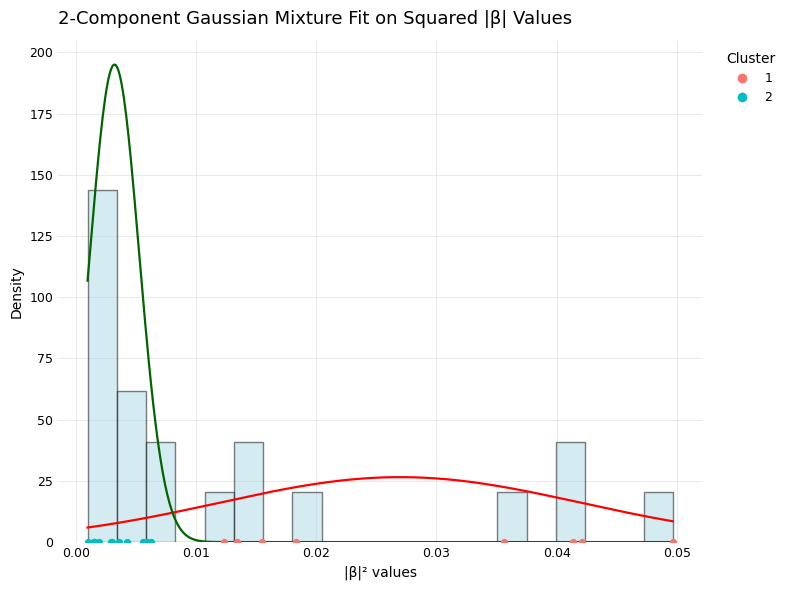

saved figure_sr4.pdf


In [4]:
# ggplot2's default two-colour hue palette, so the point colours match the published figure.
CLUSTER_COLOURS = {1: "#F8766D", 2: "#00BFC4"}
x2 = squared.ravel()
cluster = np.where(assignment == large, 1, 2)

grid = np.linspace(x2.min(), x2.max(), 500)
density_large = norm.pdf(grid, loc=means[large], scale=sigmas[large])
density_small = norm.pdf(grid, loc=means[small], scale=sigmas[small])

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(x2, bins=BINS, density=True, facecolor="lightblue", edgecolor="black", alpha=0.5, zorder=1)
ax.plot(grid, density_large, color="red", lw=1.6, zorder=3)
ax.plot(grid, density_small, color="darkgreen", lw=1.6, zorder=3)

jitter = np.random.default_rng(JITTER_SEED).uniform(-0.001, 0.001, len(x2))
for label, colour in CLUSTER_COLOURS.items():
    keep = cluster == label
    ax.scatter(x2[keep], jitter[keep], s=18, color=colour, zorder=4)

ax.set_title("2-Component Gaussian Mixture Fit on Squared |β| Values", fontsize=13, loc="left", pad=12)
ax.set_xlabel("|β|² values", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.grid(True, which="major", color="#e6e6e6", lw=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(labelsize=9, length=0)

handles = [
    Line2D([], [], marker="o", ls="none", color=colour, markersize=6, label=str(label))
    for label, colour in CLUSTER_COLOURS.items()
]
ax.legend(
    handles=handles,
    title="Cluster",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "figure_sr4.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("saved figure_sr4.pdf")

Against the published PNG: same 20 points, the same 8/12 split, the same broad red component over the
large effects and the narrow dark-green one over the small, and matching curve heights — the small
component peaks at 195 against roughly 220 read off the published panel, the large at 27 against
roughly 25. Two cosmetic differences: this is matplotlib rather than `ggplot2`'s `theme_minimal`, so
the panel background is white rather than grey, and the rug jitter comes from a seeded generator
(`position_jitter` in the original was not seeded).

## The diseases behind the two components

In [5]:
names = (
    ds.dataset(paper.release("disease") + "/disease.parquet", format="parquet")
    .to_table(columns=["id", "name"])
    .to_pydict()
)
label_of = dict(zip(names["id"], names["name"]))

order = np.argsort(per_disease["absEstimatedBeta"].to_numpy(dtype=float))
table = per_disease.iloc[order].copy()
table["squaredBeta"] = table["absEstimatedBeta"] ** 2
table["cluster"] = np.where(two.predict(table["squaredBeta"].to_numpy().reshape(-1, 1)) == large, 1, 2)
table["diseaseName"] = table["diseaseId"].map(label_of)
print(
    table[["diseaseId", "diseaseName", "studyId", "absEstimatedBeta", "squaredBeta", "cluster"]].to_string(index=False)
)

    diseaseId                           diseaseName                     studyId  absEstimatedBeta  squaredBeta  cluster
   HP_0100749                            Chest pain                GCST90480143          0.030873     0.000953        2
  EFO_0000537                          hypertension   FINNGEN_R12_I9_HYPTENSESS          0.038506     0.001483        2
  EFO_0004269                    cardiac arrhythmia FINNGEN_R12_CARDIAC_ARRHYTM          0.038919     0.001515        2
  EFO_0000341 chronic obstructive pulmonary disease FINNGEN_R12_CARDIAC_ARRHYTM          0.038919     0.001515        2
  EFO_0005251                           hypotension                GCST90478054          0.043660     0.001906        2
  EFO_0009719          artificial cardiac pacemaker                GCST90480163          0.053632     0.002876        2
  EFO_0009552                            hemorrhoid                GCST90436180          0.054919     0.003016        2
  EFO_1001207                systolic he